1. Load MNIST
2. Examine image shape
3. Review the 28×28 pixel structure
4. Manually demonstrate a convolution
5. Build a Conv2d layer
6. Inspect the resulting feature map
7. Explain channels, kernels, and feature maps

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=transform
)

In [2]:
print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])
Label: 5


In [3]:
#example of whats happening
artificial_image = torch.tensor([
    [1, 1, 1, 0, 0],
    [1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1],
    [0, 0, 0, 1, 1]
])

kernel = torch.tensor([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
])

def kernel_loop(x_pos, y_pos):
    value = 0
    for i in range(3):
        for j in range(3):
            value += artificial_image[i+x_pos][j+y_pos] * kernel[i][j]
    return value

values = torch.zeros(3, 3, dtype=torch.int64, device=device)
for x in range(3):
    for y in range(3):
        values[x][y] = kernel_loop(x,y)
print(values)

tensor([[ 3,  2,  1],
        [ 3,  1, -1],
        [ 0, -1, -2]], device='cuda:0')


In [6]:
#creates the kernel the numbers for it are learned and trained 
conv = nn.Conv2d(
    in_channels=1,#it has one channel the grayscale for RGB it would be 3
    out_channels=1, #only one filter
    kernel_size=3, #3x3 kernel
    stride=1, # kernel moves by one step
    padding=0, # no extra pixels around the image
    bias=False #There is no bias 
)

#copies the created image and kernel
with torch.no_grad():
    conv.weight.copy_(kernel.unsqueeze(0).unsqueeze(0))
input_image = artificial_image.float().unsqueeze(0).unsqueeze(0)

#uses the kernal on the image
output = conv(input_image)

print(output)
print(output.shape)

tensor([[[[ 3.,  2.,  1.],
          [ 3.,  1., -1.],
          [ 0., -1., -2.]]]], grad_fn=<ConvolutionBackward0>)
torch.Size([1, 1, 3, 3])


In [9]:
mnist_image = image.unsqueeze(0)

mnist_conv = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    stride=1,
    padding=0,
    bias=False
)

mnist_output = mnist_conv(mnist_image)

print("Input shape:", mnist_image.shape)
print("Output shape:", mnist_output.shape)

Input shape: torch.Size([1, 1, 28, 28])
Output shape: torch.Size([1, 1, 26, 26])


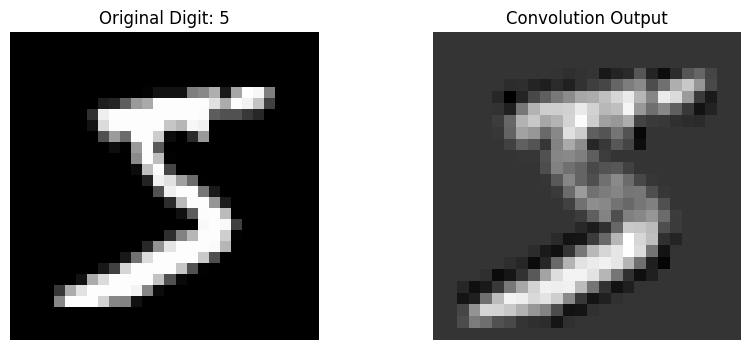

In [10]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Original Digit: {label}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mnist_output.detach().squeeze(), cmap="gray")
plt.title("Convolution Output")
plt.axis("off")

plt.show()

In [11]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [14]:
cnn = nn.Sequential(
    nn.Conv2d(
        in_channels=1,
        out_channels=16,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),

    nn.MaxPool2d(kernel_size=2),

    nn.Conv2d(
        in_channels=16,
        out_channels=32,
        kernel_size=3,
        padding=1
    ),
    nn.ReLU(),

    nn.MaxPool2d(kernel_size=2),

    nn.Flatten(),

    nn.Linear(32 * 7 * 7, 10)
).to(device)

cnn_loss_fn = nn.CrossEntropyLoss()

cnn_optimizer = torch.optim.Adam(
    cnn.parameters(),
    lr=0.001
)

images, labels = next(iter(train_loader))

images = images.to(device)

output = cnn(images)

print("Input:", images.shape)
print("Output:", output.shape)

Input: torch.Size([64, 1, 28, 28])
Output: torch.Size([64, 10])


In [28]:
#manualy do the model
#1 grayscale image
#      ↓
#16 different learned filters
#      ↓
#16 feature maps
conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=16,
    kernel_size=3,
    padding=1
)
#take images data
images, labels = next(iter(train_loader))
images = images.to(device)
conv1 = conv1.to(device)

#input the kernel through the image
output = conv1(images)

#makes it nonLinear
relu = nn.ReLU()
output = relu(output)

#Maxpooling
pool = nn.MaxPool2d(kernel_size=2)

output = pool(output)




#do it for the second convolution
#only 16 channels
conv2 = nn.Conv2d(
    in_channels=16,
    out_channels=32,
    kernel_size=3,
    padding=1
).to(device)

#input the kernel through the image
output = conv2(output)

relu = nn.ReLU()
pool = nn.MaxPool2d(kernel_size=2)

#makes it nonLinear
output = relu(output)
#Maxpooling
output = pool(output)


#Now flatten the output so it could be inputed into the model
output = output.flatten(start_dim=1).to(device)

In [29]:
fc = nn.Linear(32 * 7 * 7, 10).to(device)

output = fc(output)

print(output.shape)

torch.Size([64, 10])
